In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\jaswa\Downloads\complaints.csv\complaints.csv")     

In [2]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-09-24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",KS,67206,NaN,NaN,Web,2025-09-24,In progress,Yes,NaN,16152255
2,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
3,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453
4,2025-09-23,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,CA,93630,NaN,NaN,Web,2025-09-23,In progress,Yes,NaN,16077048


In [3]:
# Filter out only the 4 required categories
target_categories = [
    'Credit reporting, credit repair services, or other personal consumer reports',
    'Debt collection',
    'Consumer Loan',
    'Mortgage'
]

# Keep only rows where complaint text exists and product is in target
df = df[df['Consumer complaint narrative'].notnull()]
df = df[df['Product'].isin(target_categories)]

# Map product to numeric labels
label_map = {
    'Credit reporting, credit repair services, or other personal consumer reports': 0,
    'Debt collection': 1,
    'Consumer Loan': 2,
    'Mortgage': 3
}
df['label'] = df['Product'].map(label_map)

# Keep only needed columns
df = df[['Consumer complaint narrative', 'label']]
df.head()


,Consumer complaint narrative,label
3,These are not my accounts.,0
46,"I wrote three requests, the unverified account...",0
76,I have filed a dispute in regards to the incor...,0
90,There are five closed accounts from XXXX on my...,0
98,On XX/XX/2018 XXXX XXXX and XXXX XXXX were sen...,0


In [4]:
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords (only once)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Define cleaning function
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation & numbers
    words = text.split()  # Tokenize
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

# Apply cleaning to each row
df['clean_text'] = df['Consumer complaint narrative'].apply(clean_text)

# Show the cleaned text
df[['Consumer complaint narrative', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaswa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Consumer complaint narrative,clean_text
3,These are not my accounts.,accounts
46,"I wrote three requests, the unverified account...",wrote three requests unverified accounts liste...
76,I have filed a dispute in regards to the incor...,filed dispute regards incorrect information th...
90,There are five closed accounts from XXXX on my...,five closed accounts xxxx credit reports still...
98,On XX/XX/2018 XXXX XXXX and XXXX XXXX were sen...,xxxx xxxx xxxx xxxx xxxx sent letters validati...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Step 1: Train-Test split
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Convert text into TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 3: Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_vec, y_train)

C:\Users\jaswa\anaconda34\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93    161743
           1       0.87      0.83      0.85     72467
           2       0.68      0.36      0.47      1922
           3       0.92      0.93      0.93     26813

    accuracy                           0.91    262945
   macro avg       0.85      0.76      0.79    262945
weighted avg       0.90      0.91      0.90    262945



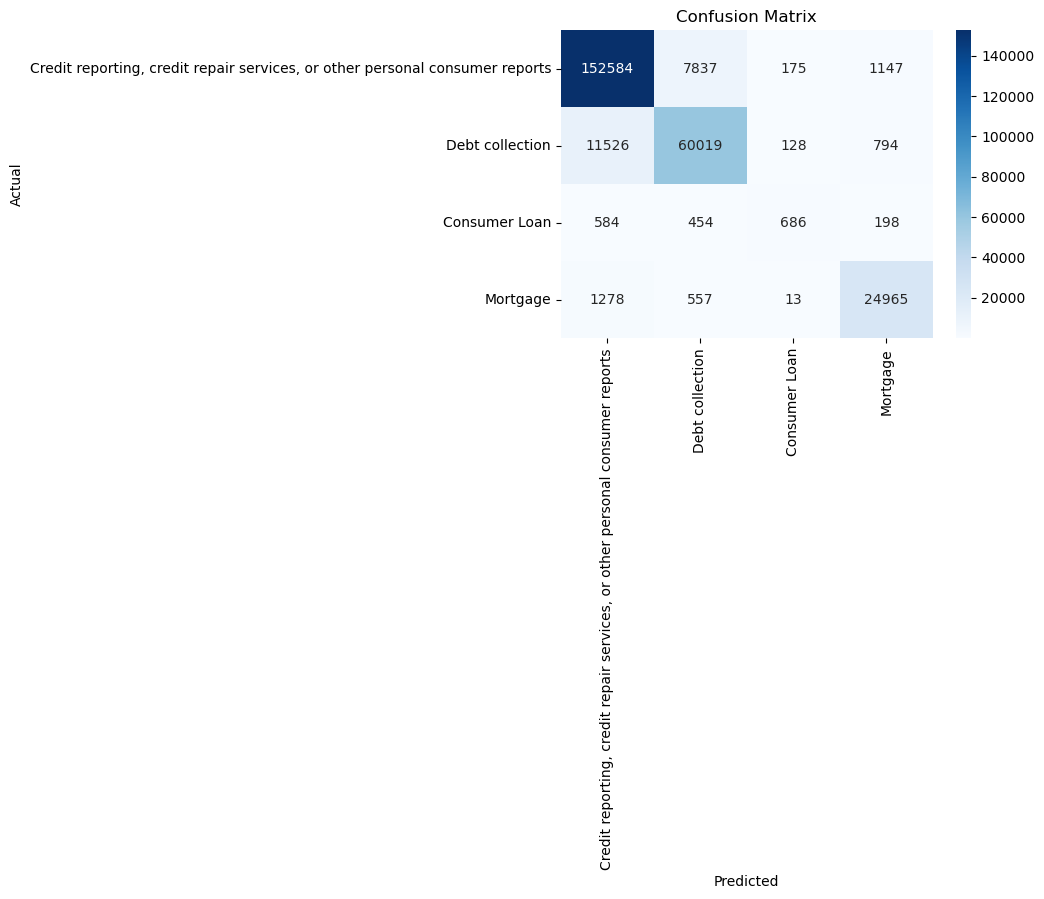

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test_vec)

# Show classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Reverse label map for display
reverse_label_map = {v: k for k, v in label_map.items()}

# Function to make predictions
def predict_complaint(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    label = model.predict(vector)[0]
    return reverse_label_map[label]

# Try with your own sample complaint
sample = "The bank is constantly asking me for a mortgage I do not owe"
result = predict_complaint(sample)

print("Predicted Category:", result)


Predicted Category: Mortgage
